In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
import os
plt.style.use("parallel ent paper.mplstyle")

In [2]:
import os
import json

def _from_str(s):
    if s == "" or s is None:
        return None
    try:
        return json.loads(s)
    except Exception:
        pass
    try:
        return int(s)
    except Exception:
        pass
    try:
        return float(s)
    except Exception:
        pass
    if s == "True":
        return True
    if s == "False":
        return False
    return s

def load_cases_txt(filename):
    filepath = filename

    INFO_to_save = {}
    rows = []
    headers = None

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # INFO block
            if line.startswith("#"):
                if "\t" in line:
                    name, val = line[1:].split("\t", 1)
                    INFO_to_save[name.strip()] = _from_str(val.strip())
                continue

            # header row
            if headers is None:
                headers = line.split("\t")
                continue

            # data row
            values = line.split("\t")
            row = {}
            for i in range(len(headers)):
                row[headers[i]] = _from_str(values[i]) if i < len(values) else None
            rows.append(row)

    # rebuild fid_cases_per_EHE structure
    fid_cases_per_EHE = []

    for row in rows:
        EHE_idx = row["EHE_idx"]

        while len(fid_cases_per_EHE) <= EHE_idx:
            fid_cases_per_EHE.append([])

        case = {}
        for k, v in row.items():
            if k != "EHE_idx":
                case[k] = v

        fid_cases_per_EHE[EHE_idx].append(case)

    return INFO_to_save, fid_cases_per_EHE

### NOTE 
these simulation files are the same as the ones in the corresponding data repository for "Single-gate, multipartite entanglement on a room-temperature quantum register"

In [3]:
INFO_to_save, fid_cases_per_EHE = load_cases_txt("fid_cases_per_EHE_1ns.txt") #doesn't matter which file gives the constant info to save
_, speed_cases_per_EHE = load_cases_txt("speed_cases_per_EHE_1ns.txt")

C13_fractional_abundance = INFO_to_save["C13_fractional_abundance"]
N_NVs = INFO_to_save["N_NVs"]
frac_pass = 35.9

### Helepr functions

In [4]:
L_max = 0
N_configurations = len(fid_cases_per_EHE) #doesn't matter which gets used here, it's all about number of qubits here, not speed or fidelity
for cases in fid_cases_per_EHE:
    for case in cases:
        L = len(case["C_idxs"])
        if L > L_max:
            L_max = L
Ls = range(2,L_max+1)

L_counts_per_configuration = []
for cases in fid_cases_per_EHE:
    L_counts = np.zeros(L_max+1)
    for case in cases:
        L = len(case["C_idxs"])
        L_counts[L] += 1
    L_counts_per_configuration.append(L_counts)
L_counts_per_configuration = np.array(L_counts_per_configuration)
L_counts_per_configuration_plot = np.transpose(L_counts_per_configuration)[2:]
max_count = np.max(L_counts_per_configuration_plot)

def get_durations_per_L(L,cases_per_EHE):
    configuration_numbers = [] #nonunique
    case_numbers = [] #unique (for plotting)
    parallel_durations = []
    k2_durations = []
    k3_durations = []
    case_count = 0
    for iconfiguration,cases in enumerate(cases_per_EHE):
        for case in cases:
            L_case = len(case["C_idxs"])
            if L_case == L:
                parallel_durations.append(case["parallel_duration"])
                k2_durations.append(case["k2_seq_duration"])
                k3_durations.append(case["k3_seq_duration"])
                configuration_numbers.append(iconfiguration)
                case_numbers.append(case_count)
                case_count += 1
    return configuration_numbers,case_numbers,np.array(parallel_durations),np.array(k2_durations),np.array(k3_durations)

### Plotting

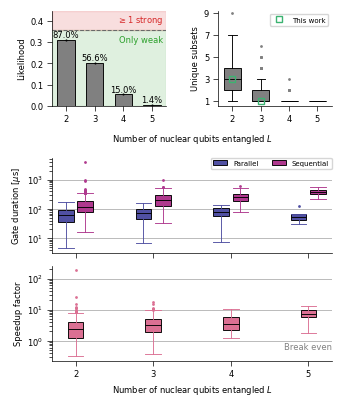

In [5]:
fig = plt.figure(figsize=(3.3, 3.95), constrained_layout=True)
gs = fig.add_gridspec(3, 2)

axs = []
axs.append(fig.add_subplot(gs[0, 0]))   # top-left
axs.append(fig.add_subplot(gs[0, 1]))   # top-right
axs.append(fig.add_subplot(gs[1, :]))   # middle (span)
axs.append(fig.add_subplot(gs[2, :]))   # bottom (span)

QEL_color = "mediumseagreen"
whisker_LT = 0.65

#==================================================================================================================
# Plot 1: Probability and unique subsets
#==================================================================================================================

for i, L_counts in enumerate(L_counts_per_configuration_plot):
    count_per_config = 0
    for HF_cutoff in L_counts:
        if HF_cutoff > 0:
            count_per_config += 1

    frac_weak = round(count_per_config / N_NVs, 3)
    frac_all = round(count_per_config * (frac_pass/100) / N_NVs, 3)

    # bar plot (left)
    bars = axs[0].bar([i+2], frac_all, color="grey", edgecolor="black", width=0.6, linewidth=whisker_LT)
    for bar in bars:
        axs[0].plot(bar.get_x() + bar.get_width()/2, bar.get_height(), marker='.', color='black', markersize=1, zorder=100)
    axs[0].annotate(str(round(frac_weak*100, 1)) + "%", (i+2, frac_all), ha="center", va="bottom",fontsize=6)

    # box plot (right)
    L_counts_given_parallel_mask = L_counts > 0
    L_counts_given_parallel = L_counts[L_counts_given_parallel_mask]
    bplot = axs[1].boxplot(L_counts_given_parallel, positions=[i+2], widths=0.6, patch_artist=True)

    bplot["boxes"][0].set_facecolor("grey")
    bplot["boxes"][0].set_edgecolor("black")
    bplot["medians"][0].set_color("black")
    bplot["medians"][0].set_linewidth(whisker_LT)
    for box in bplot["boxes"]:
        box.set_linewidth(whisker_LT)
    for whisker in bplot["whiskers"]:
        whisker.set_color("black")
        whisker.set_linewidth(whisker_LT)
    for cap in bplot["caps"]:
        cap.set_color("black")
        cap.set_linewidth(whisker_LT)
    for flier in bplot["fliers"]:
        flier.set_marker(".")
        flier.set_markersize(2)
        flier.set_markerfacecolor("None")
        flier.set_markeredgecolor("grey")

# plot QEL results
axs[1].plot([2], [3], marker="s", markersize=4, linestyle="None",markeredgecolor=QEL_color, markerfacecolor="none", markeredgewidth=1,zorder=1000)
axs[1].plot([3], [1], marker="s", markersize=4, linestyle="None",markeredgecolor=QEL_color, markerfacecolor="none", markeredgewidth=1,label="This work",zorder=1000)

axs[0].set_ylabel("Likelihood")
axs[0].set_xticks(Ls)
axs[0].set_yticks([0,0.1,0.2,0.3,0.4])
ytop = 0.45
ybot = frac_pass/100
axs[0].set_ylim(top=ytop)
axs[0].axhspan(ybot,ytop,color="tab:red",alpha=0.15)
# axs[0].annotate(r"Has $\geq1$ strong",(3.5,ybot + (ytop - ybot)/2),ha="center",va="center",color="tab:red",fontsize=6)
axs[0].annotate(r"$\geq1$ strong",(5.4,ybot + (ytop - ybot)/2),ha="right",va="center",color="tab:red",fontsize=6)
axs[0].axhspan(0,ybot,color="tab:green",alpha=0.15,zorder=-10)
axs[0].annotate("Only weak",(5.4,ybot - (ytop - ybot)/2),ha="right",va="center",color="tab:green",fontsize=6)
xlim = axs[0].get_xlim()
axs[0].plot(xlim,[ybot,ybot],color="dimgrey",linestyle="--",linewidth=0.75)
axs[0].set_xlim(xlim)

axs[1].set_ylabel("Unique subsets")
axs[1].set_ylim([0.6,9.2])
axs[1].set_yticks([1,3,5,7,9])
axs[1].set_xticks(Ls)
axs[1].legend(fontsize=5)

#==================================================================================================================
# Plot 2: Durations
#==================================================================================================================

ax = axs[2]

for iL, L in enumerate(Ls):
    _, _, parallel_durations_speed, k2_durations, _ = get_durations_per_L(L,speed_cases_per_EHE)
    data_to_plot = [parallel_durations_speed, k2_durations]
    labels = ["Parallel", "Sequential"]
    colors = ["#5050a2","#af398e"] #para, seq
    delta = 0.25
    widths = 0.2

    for idata,data in enumerate(data_to_plot):
        if iL == 0:
            label = labels[idata]
        else:
            label = None
        pos = (iL - 0.5*delta) + delta*idata
        bplot = ax.boxplot(data, positions=[pos], patch_artist=True, label=label, widths=widths,capwidths=widths)
        if len(data) == 1:
            y = np.median(data)
            ax.plot([pos],[y],marker="o",color=colors[idata],linestyle="None")

        #configure the colors
        bplot["boxes"][0].set_facecolor(colors[idata])
        bplot["boxes"][0].set_edgecolor("black")
        bplot["medians"][0].set_color("black")
        bplot["medians"][0].set_linewidth(whisker_LT)
        for box in bplot["boxes"]:
            box.set_linewidth(whisker_LT)
        for whisker in bplot["whiskers"]:
            whisker.set_color(colors[idata])
            whisker.set_linewidth(whisker_LT)
        for cap in bplot["caps"]:
            cap.set_color(colors[idata])
            cap.set_linewidth(whisker_LT)
        for flier in bplot["fliers"]:
            flier.set_marker(".")
            flier.set_markersize(2)
            flier.set_markerfacecolor("None")
            flier.set_markeredgecolor(colors[idata])

ax.set_ylabel(r'Gate duration [$\mu$s]')
ax.set_xticks(range(len(Ls)))
ax.set_xticklabels([])
ax.set_yscale("log")
ax.set_xlim([-0.3,3.3])

handles, labels = ax.get_legend_handles_labels()
legend_handles = [
    handles[labels.index("Parallel")],
    handles[labels.index("Sequential")]
]
legend_labels = ["Parallel","Sequential","This work"]
ax.legend(legend_handles, legend_labels, loc="upper right", borderaxespad=0, title_fontsize=5, fontsize=5, ncol=3)
ax.grid(axis="y",color="grey",linewidth=0.5,alpha=0.75)

#==================================================================================================================
# Plot 3: speed ups 
#==================================================================================================================

ax = axs[3]

for iL, L in enumerate(Ls):
    _, _, parallel_durations_speed, k2_durations, _ = get_durations_per_L(L, speed_cases_per_EHE)

    ratio_k2_speed = k2_durations / parallel_durations_speed

    data_to_plot = [ratio_k2_speed]
    colors = ["palevioletred"]
    delta = 0.25
    widths = 0.2

    for idata, data in enumerate(data_to_plot):

        pos = iL
        bplot = ax.boxplot(data, positions=[pos], patch_artist=True, widths=widths, capwidths=widths)

        if len(data) == 1:
            y = np.median(data)
            ax.plot([pos], [y], marker="o", color=colors[idata], linestyle="None")

        # configure the colors
        bplot["boxes"][0].set_facecolor(colors[idata])
        bplot["boxes"][0].set_edgecolor("black")
        bplot["medians"][0].set_color("black")
        bplot["medians"][0].set_linewidth(whisker_LT)
        for box in bplot["boxes"]:
            box.set_linewidth(whisker_LT)
        for whisker in bplot["whiskers"]:
            whisker.set_color(colors[idata])
            whisker.set_linewidth(whisker_LT)
        for cap in bplot["caps"]:
            cap.set_color(colors[idata])
            cap.set_linewidth(whisker_LT)
        for flier in bplot["fliers"]:
            flier.set_marker(".")
            flier.set_markersize(2)
            flier.set_markerfacecolor("None")
            flier.set_markeredgecolor(colors[idata])

ax.annotate("Break even", (1, 0.15), xycoords="axes fraction", ha="right", va="center", color="grey")

ax.set_ylabel(r'Speedup factor')
ax.set_xticks(range(len(Ls)))
ax.set_xticklabels(Ls)
ax.set_yscale("log")
ax.set_xlim([-0.3,3.3])
ax.grid(axis="y", color="grey", linewidth=0.5, alpha=0.75)

ax.set_xlabel(r"Number of nuclear qubits entangled $L$",fontsize=6)
axs[2].set_title(r"Number of nuclear qubits entangled $L$"+"\n",fontsize=6)

plt.show()